<a href="https://colab.research.google.com/github/BalkeesRekik/DS3001/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

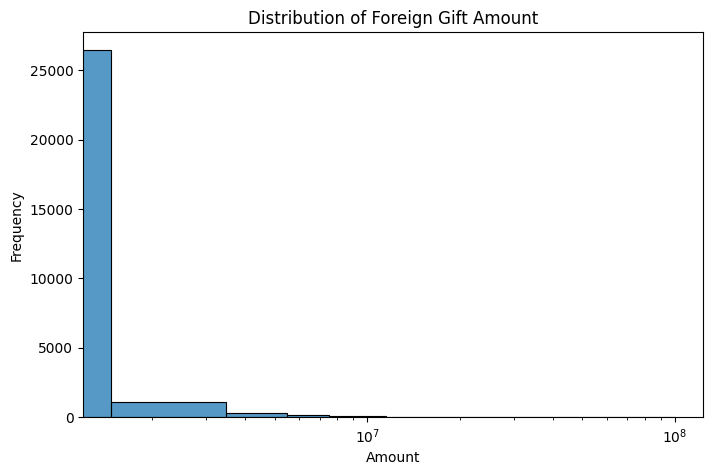

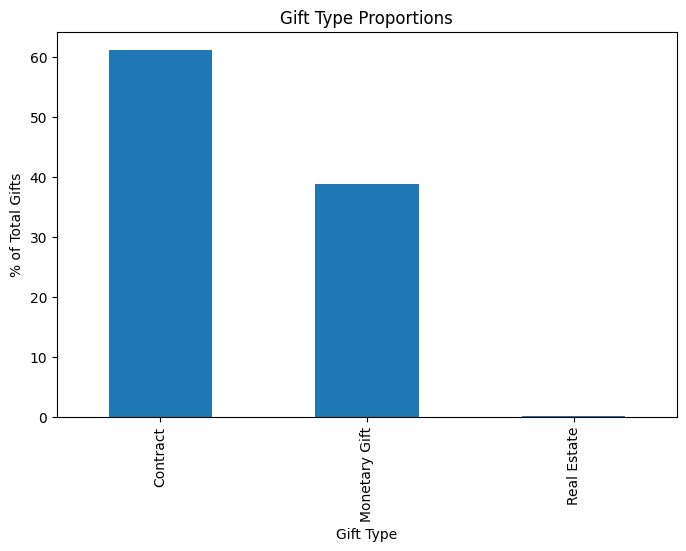

Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


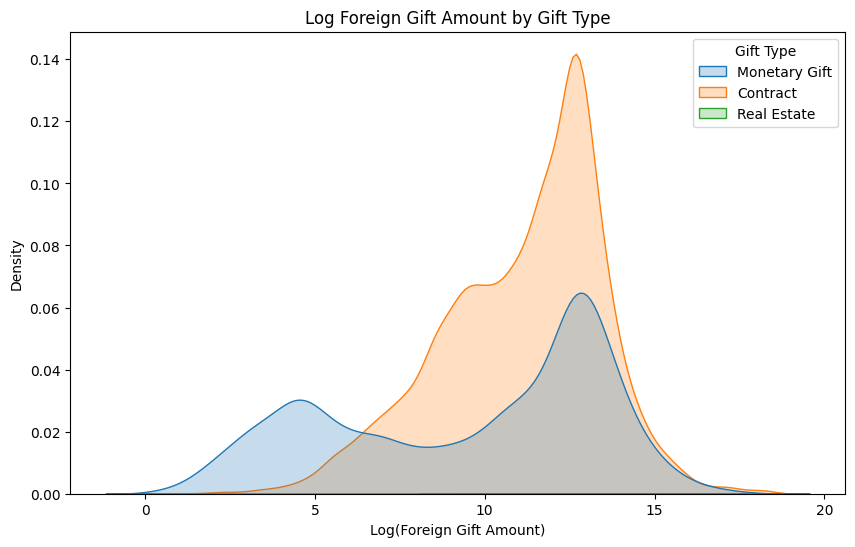

Top 15 Countries by Number of Gifts:
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 Countries by Total Amount Given:
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALI

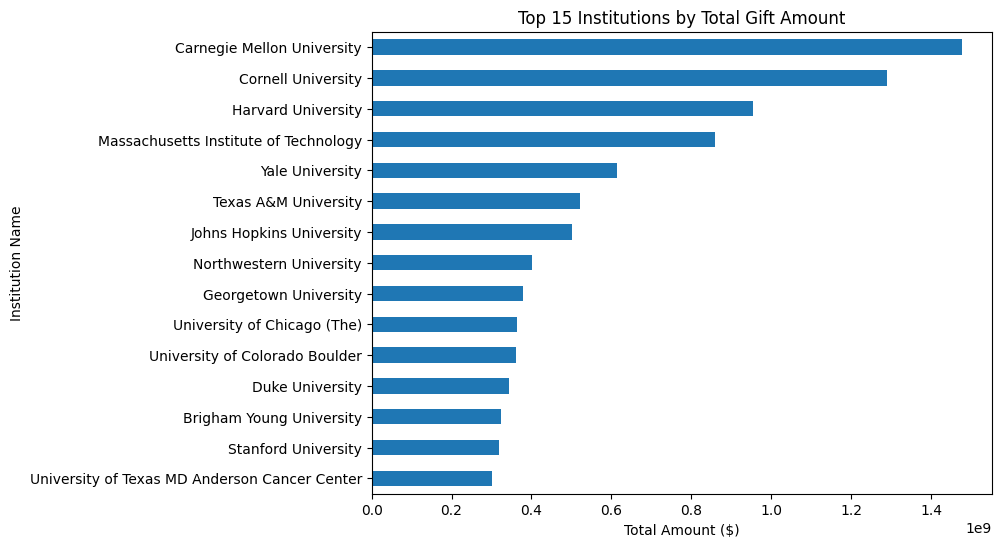

Top 10 Giftors by Total Amount Given:
 Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64


In [8]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('/content/ForeignGifts_edu (1).csv')
df.head()

plt.figure(figsize=(8, 5))
sns.histplot(df['Foreign Gift Amount'], bins=50, kde=False)
plt.title('Distribution of Foreign Gift Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xscale('log')
plt.show()

# Description
df['Foreign Gift Amount'].describe()

gift_counts = df['Gift Type'].value_counts(normalize=True) * 100  # Percentage
gift_counts.plot(kind='bar', title='Gift Type Proportions', figsize=(8,5))
plt.ylabel('% of Total Gifts')
plt.show()

print(gift_counts)

df['log_gift'] = np.log1p(df['Foreign Gift Amount'])  # log(1 + x) to handle 0s

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='log_gift', hue='Gift Type', fill=True)
plt.title('Log Foreign Gift Amount by Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')
plt.show()

# Top by number
top_countries_count = df['Country of Giftor'].value_counts().head(15)
print("Top 15 Countries by Number of Gifts:\n", top_countries_count)

# Top by total gift amount
top_countries_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'] \
                         .sum().sort_values(ascending=False).head(15)
print("\nTop 15 Countries by Total Amount Given:\n", top_countries_amount)


# Top by amount
top_countries_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

print("Top 15 by Number of Gifts:\n", top_countries_count)
print("\nTop 15 by Amount of Gifts:\n", top_countries_amount)

top_institutions = df.groupby('Institution Name')['Foreign Gift Amount'] \
                     .sum().sort_values(ascending=False).head(15)

top_institutions.plot(kind='barh', figsize=(8,6), title='Top 15 Institutions by Total Gift Amount')
plt.xlabel('Total Amount ($)')
plt.gca().invert_yaxis()
plt.show()


top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'] \
                .sum().sort_values(ascending=False).head(10)

print("Top 10 Giftors by Total Amount Given:\n", top_giftors)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 10 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Month                                                                                        623 non-null    object
 1   Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)                 623 non-null    int64 
 2   Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)                623 non-null    int64 
 3   Crude Oil Rotary Rigs in Operation, Total (Number of Rigs)                                   623 non-null    object
 4   Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)                                 623 non-null    object
 5   Crude Oil and Natural Gas Rotary Rigs in Op

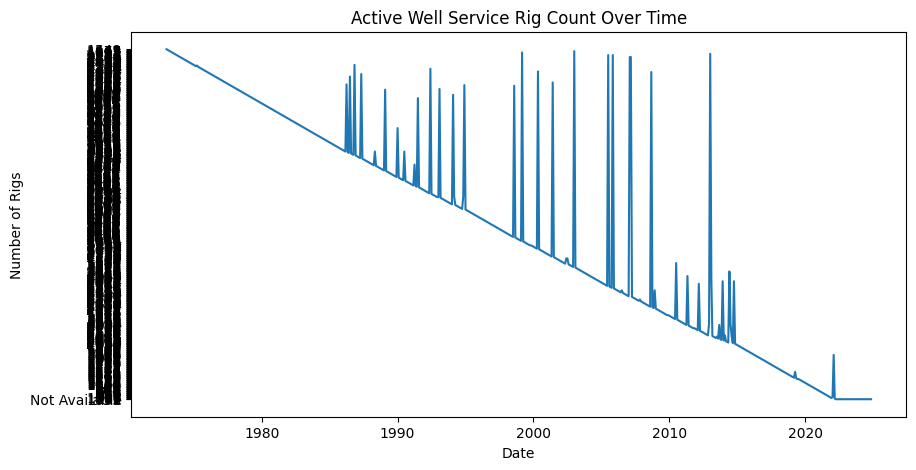

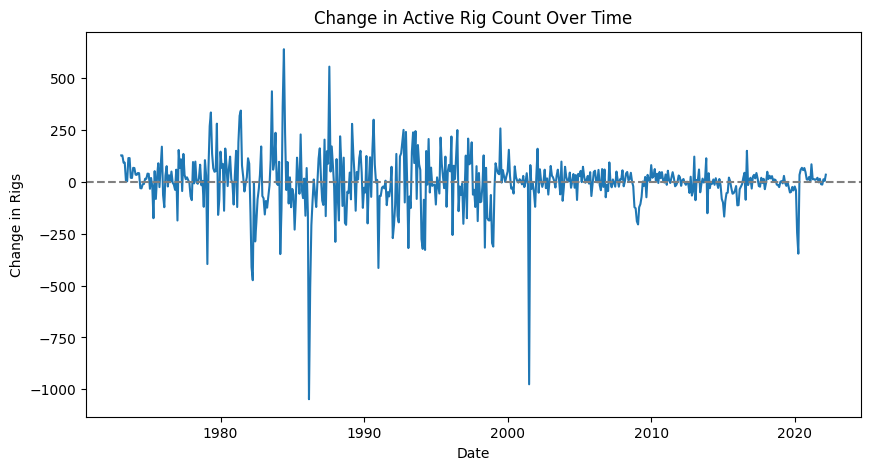

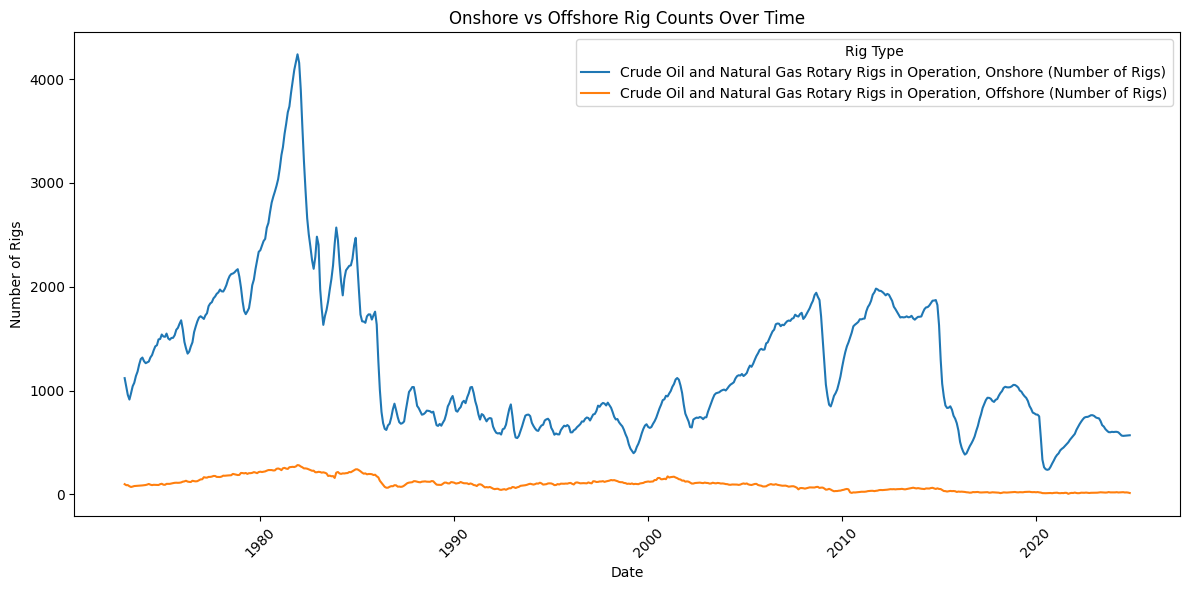

In [5]:
# Q4

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drilling_rigs.csv')
print(df.info())
print(df.head())

df['time'] = pd.to_datetime(df['Month'], format='mixed')
df = df.sort_values('time')  # Make sure it's in time order

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='time', y='Active Well Service Rig Count (Number of Rigs)')
plt.title('Active Well Service Rig Count Over Time')
plt.ylabel('Number of Rigs')
plt.xlabel('Date')
plt.show()

# Convert to numeric (force invalid values to NaN)
df['Active Well Service Rig Count (Number of Rigs)'] = pd.to_numeric(
    df['Active Well Service Rig Count (Number of Rigs)'], errors='coerce'
)

# Now compute the difference
df['Rig Count Change'] = df['Active Well Service Rig Count (Number of Rigs)'].diff()

# Plot it
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='time', y='Rig Count Change')
plt.title('Change in Active Rig Count Over Time')
plt.ylabel('Change in Rigs')
plt.xlabel('Date')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

melted_df = df.melt(
    id_vars='time',
    value_vars=[
        'Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)',
        'Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)'
    ],
    var_name='Rig Type',
    value_name='Count'
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_df, x='time', y='Count', hue='Rig Type')
plt.title('Onshore vs Offshore Rig Counts Over Time')
plt.ylabel('Number of Rigs')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
